*Content of this notebook*: 
This notebook contains some more detailed analysis of the Somite_HOXKO cluster found when we merged all samples. 
It also contains some additional figures requested during the process of the revision. 

In [1]:
!conda info --envs

# conda environments:
#
base                     C:\Users\aleja\anaconda3
CommonOperations         C:\Users\aleja\anaconda3\envs\CommonOperations
scRNA_env                C:\Users\aleja\anaconda3\envs\scRNA_env
scvelo_env               C:\Users\aleja\anaconda3\envs\scvelo_env
singlecellEnv            C:\Users\aleja\anaconda3\envs\singlecellEnv
textenv               *  C:\Users\aleja\anaconda3\envs\textenv



In [2]:
import os

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy
import matplotlib.pyplot as plt
import seaborn as sns
sc.settings.verbosity = 3                
sc.logging.print_versions()  
sc.settings.set_figure_params(dpi=80, facecolor='white')

-----
anndata     0.10.7
scanpy      1.10.0
-----
PIL                         8.4.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        23.2.0
attrs                       23.2.0
babel                       2.14.0
backcall                    0.2.0
bottleneck                  1.3.7
brotli                      NA
certifi                     2024.08.30
cffi                        1.16.0
chardet                     5.2.0
charset_normalizer          3.3.2
cloudpickle                 3.0.0
colorama                    0.4.6
comm                        0.2.1
cycler                      0.12.1
cython_runtime              NA
cytoolz                     0.12.3
dask                        2024.2.0
dateutil                    2.8.2
debugpy                     1.8.1
decorator                   5.1.1
defusedxml                  0.7.1
exceptiongroup              1.2.0
executing                   2.0.1
fastjsonschema              NA

## PART 1: CDH11 

### Loading data 

In [4]:
adata = sc.read_h5ad('D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/H5AD/20241113_HOXsamples_all_qc_filtered_dr_REGSCALLING_clustered_anno.h5ad')

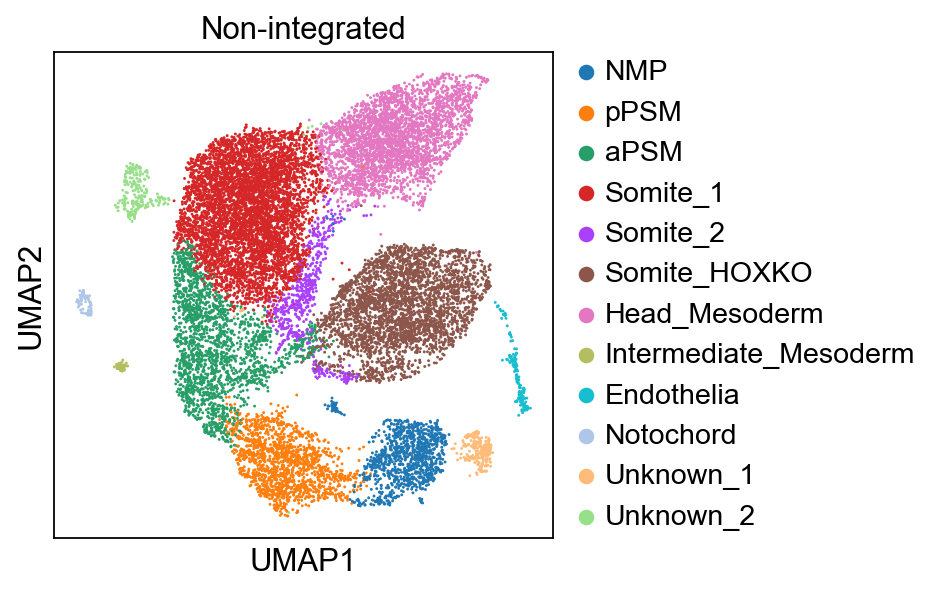

In [5]:
sc.pl.umap(adata, color='annotation', title='Non-integrated')

### Step 1: Comparing the Somite_HOXKO cluster to the rest of the clusters

ranking genes
    finished: added to `.uns['wilcoxon_annotation']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:08)


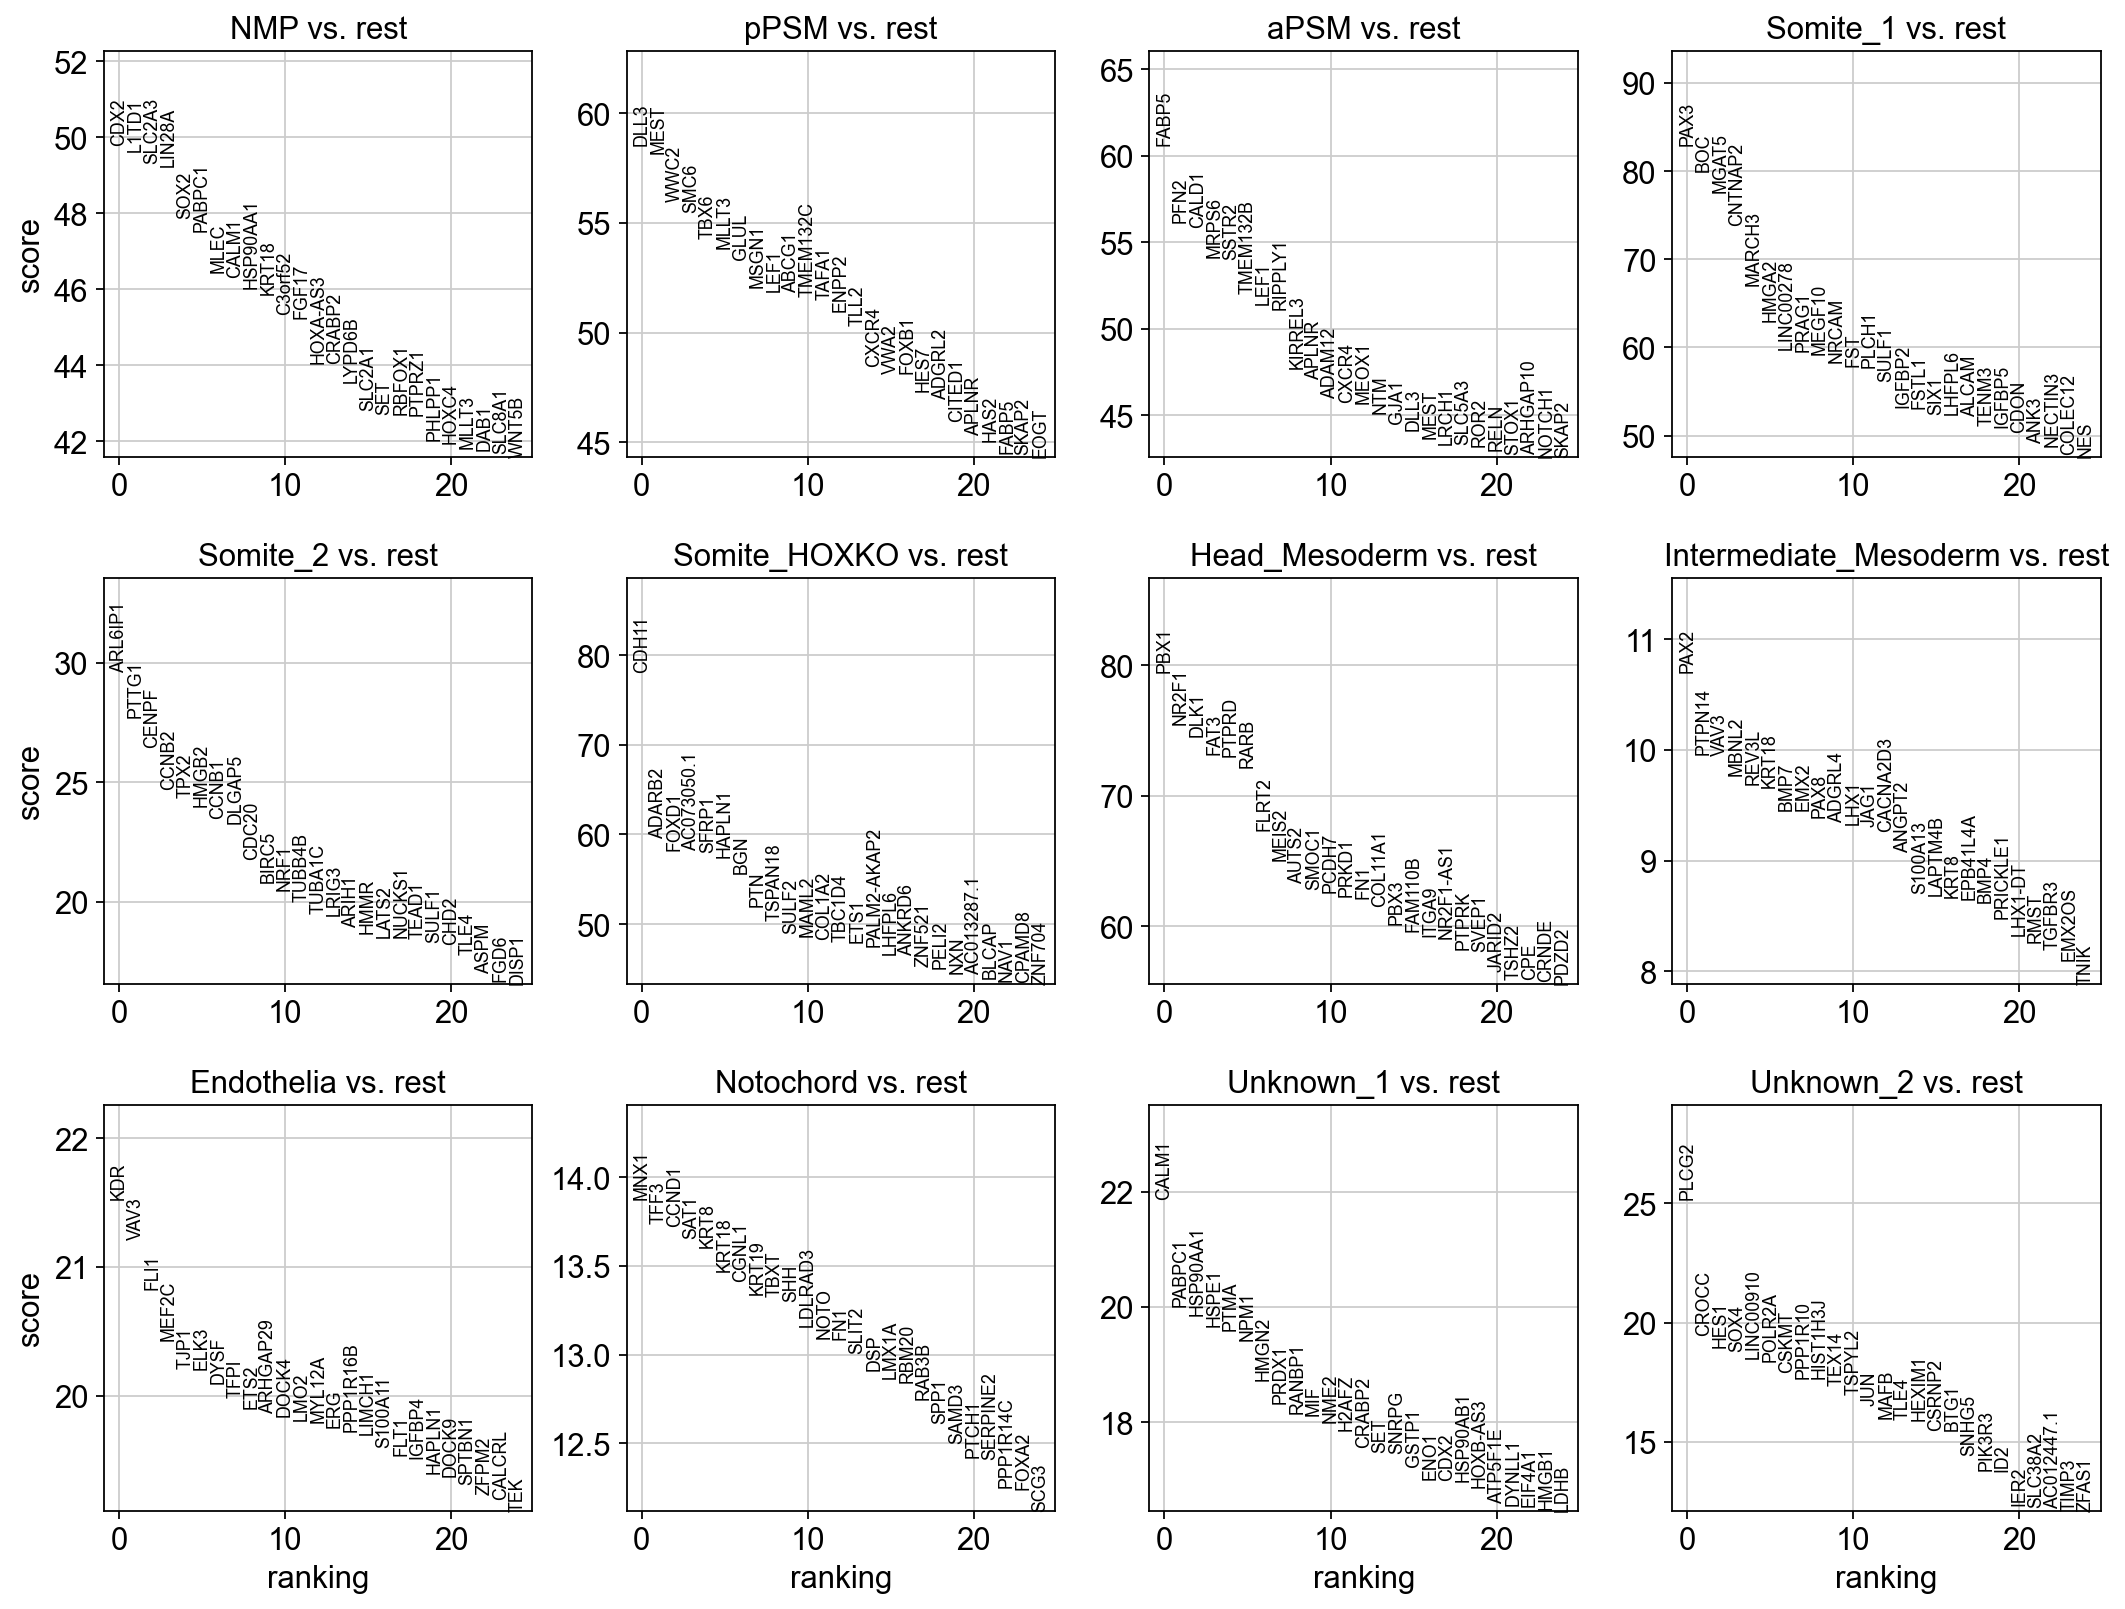

In [6]:
sc.tl.rank_genes_groups(adata, groupby='annotation', method='wilcoxon', key_added = "wilcoxon_annotation")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key="wilcoxon_annotation", save="20260107_HOX_REGSCALE_Wilcoxon_EachClusterAgainstRest.pdf")

CDH11 comes up when comparing Somite_HOXKO vs rest

### Step 2: Comparing the Somite_HOXKO cluster to the Somite_1 (main Somite) cluster

ranking genes
    finished: added to `.uns['wilcoxon_annotation_vsSomite1']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:04:02)


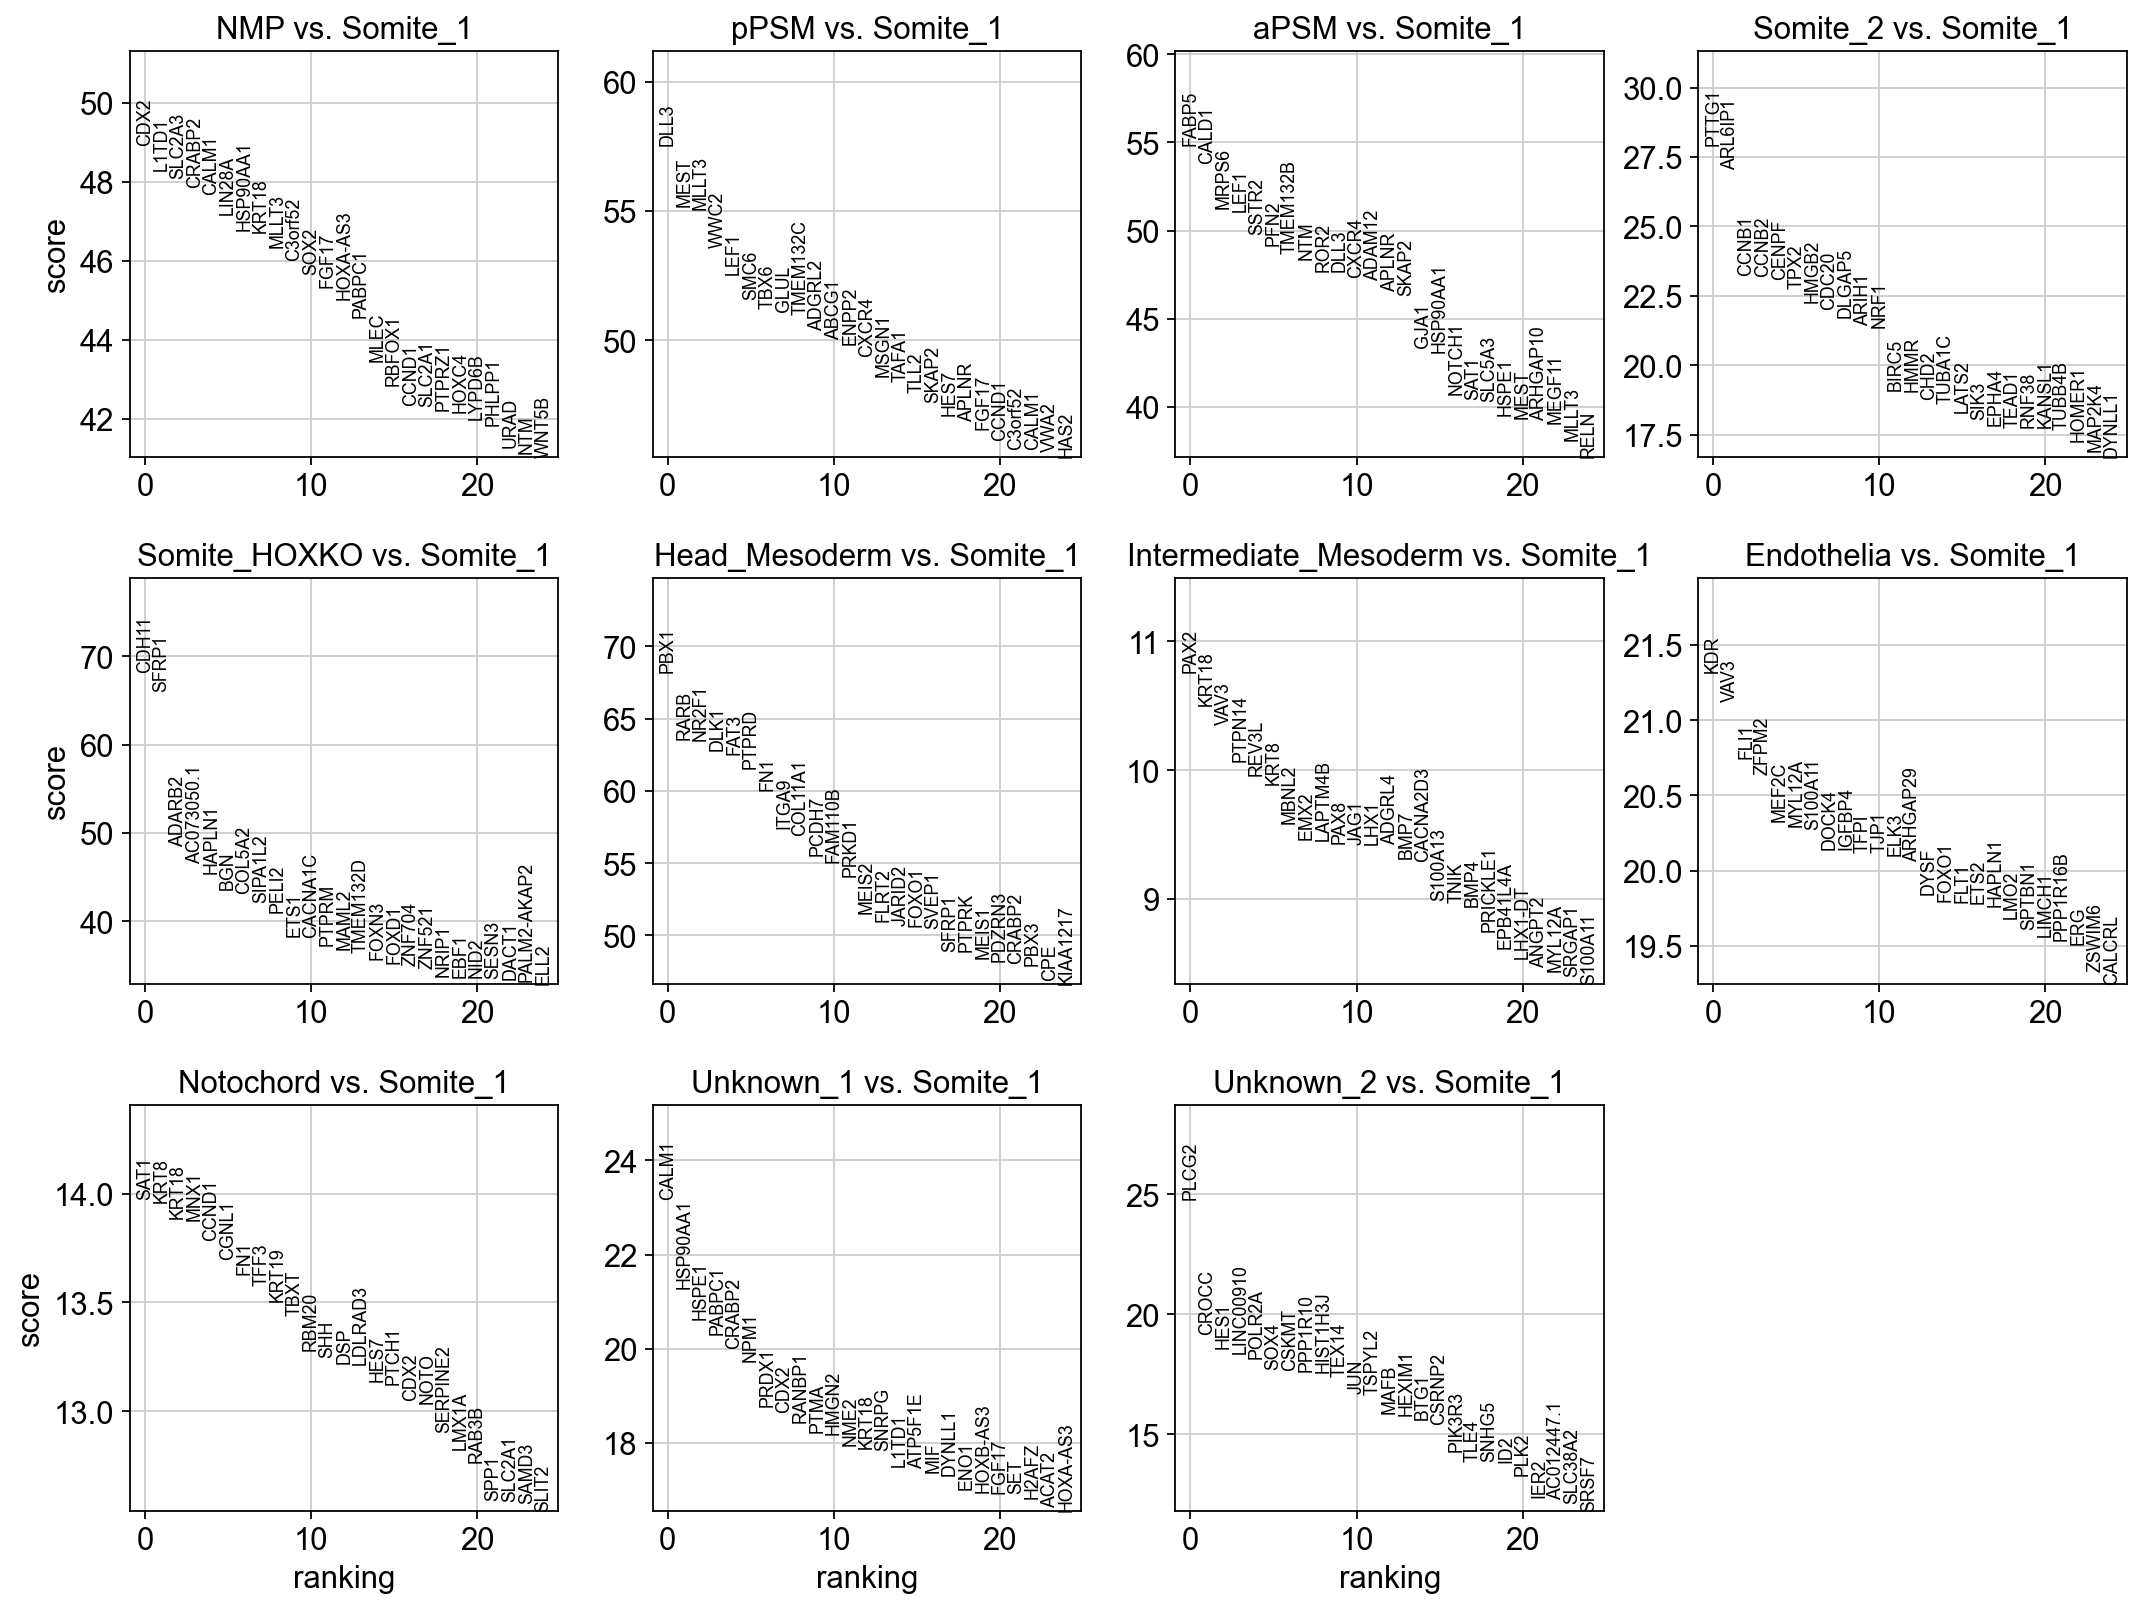

In [7]:
sc.tl.rank_genes_groups(adata, 'annotation', reference="Somite_1", method='wilcoxon', key_added = "wilcoxon_annotation_vsSomite1")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key="wilcoxon_annotation_vsSomite1",save="20260107_HOX_REGSCALE_Wilcoxon_EachClusterAgainstSomite1.pdf")

### This will compare each cluster to Somite_1 (including Somite_HOXKO, which is the one we want to inspect)

The highest scoring genes are CDH11 and SFRP1

In [8]:
# If needed we can get the list of DEG
result = adata.uns['wilcoxon_annotation']
groups = result['names'].dtype.names
df = pd.DataFrame(
{group + '_' + key[:1]: result[key][group]
for group in groups for key in ['names','logfoldchanges','pvals','pvals_adj']})
df.to_csv('D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/CSV/Revision_2025/20260107_HOX_singlecell_REG_SCALL_wilcoxon_allDEG.csv')

In [9]:
# If needed we can get the list of DEG
result = adata.uns['wilcoxon_annotation_vsSomite1']
groups = result['names'].dtype.names
df = pd.DataFrame(
{group + '_' + key[:1]: result[key][group]
for group in groups for key in ['names','logfoldchanges','pvals','pvals_adj']})
df.to_csv('D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/CSV/Revision_2025/20260107_HOX_singlecell_REG_SCALL_SOMITEHOXKOvsSOMITE1_wilcoxon_allDEG.csv')

In [10]:
# We can also parse the list of DEG by significance and LogFC:
# 1. Extract DEGs for Somite_HOXKO (compared to Somite_1)
df_hoxko_vs_somite1 = sc.get.rank_genes_groups_df(
    adata, 
    group='Somite_HOXKO', 
    key='wilcoxon_annotation_vsSomite1'
)

# 2. Filter for significant genes
sig_genes_hoxko_vs_somite1 = df_hoxko_vs_somite1[
    (df_hoxko_vs_somite1['pvals_adj'] < 0.05) & 
    (abs(df_hoxko_vs_somite1['logfoldchanges']) > 0.58)
]

sig_genes_hoxko_vs_somite1.to_csv('D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/CSV/Revision_2025/20260107_HOX_singlecell_REG_SCALL_SOMITEHOXKOvsSOMITE1_wilcoxon_parsedDEG.csv')

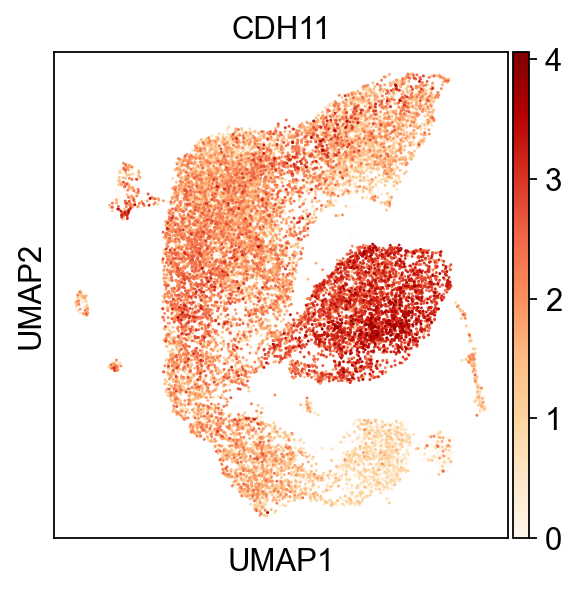

In [11]:
sc.pl.umap(adata, color='CDH11',color_map="OrRd", save="20260107_HOXallsamples_REGSCALLING_CDH11.pdf")

### Checking the expression of CDH11 and others in the WT and HOX_KO datasets sepparately

In [12]:
WT = sc.read_h5ad('D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/H5AD/20241113_WT_qc_filtered_dr_clustered_ano.h5ad')

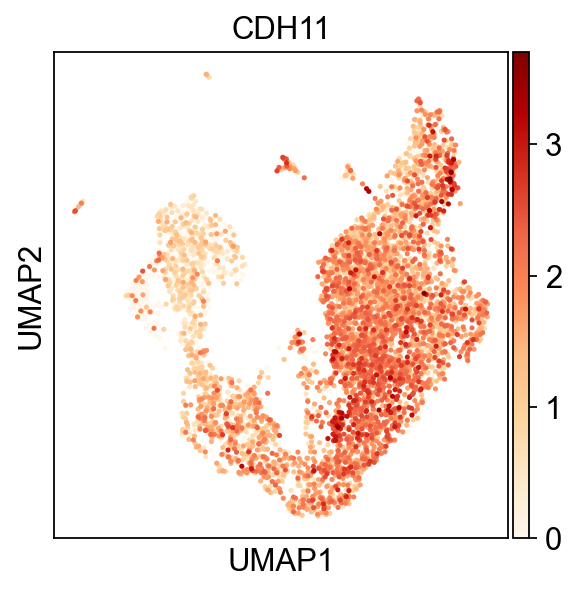

In [13]:
sc.pl.umap(WT, color='CDH11',color_map="OrRd", save="20260107_WT_UMAP_CDH11.pdf")

In [14]:
HOXKO = sc.read_h5ad('D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/H5AD/20241113_HOXKO_qc_filtered_dr_clustered_ano.h5ad')

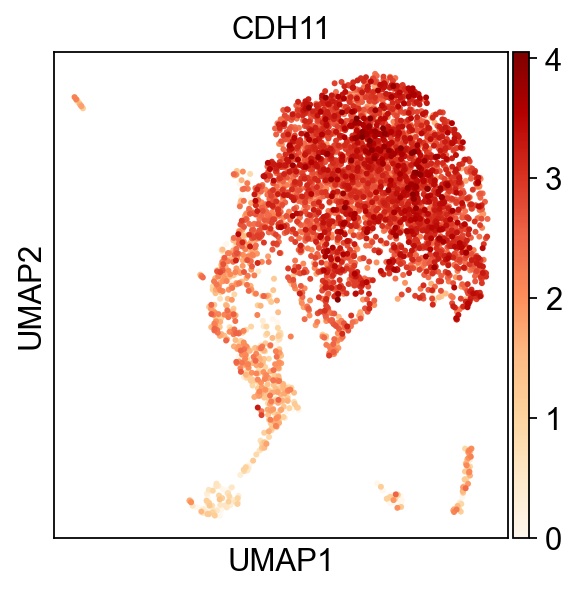

In [15]:
sc.pl.umap(HOXKO, color='CDH11',color_map="OrRd", save="20260107_HOXKO_UMAP_CDH11.pdf")

We can also plot the expression of CDH11 using a violin plot in the integrated (Harmony) dataset

In [16]:
Integrated = sc.read_h5ad('D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/H5AD/20241113_HOXsamples_all_qc_filtered_dr_Harmony_clustered_anno.h5ad')

In [17]:
adata_subset = Integrated[Integrated.obs['annotation'].isin(['NMP', 'pPSM','aPSM',"Somite_1",
                     'Somite_2', 'Head_Mesoderm'])].copy() # we subset the most relevant clusters for further analysis 

In [18]:
adata_subset.obs['annotation_short'] = (
    adata_subset.obs["annotation"]
    .map(lambda x: {"Somite_1": "Somite", "Somite_2": "Somite"}.get(x, x))
    .astype("category")
)

In [19]:
adata_subset.obs['annotation_short'] = adata_subset.obs['annotation_short'].cat.reorder_categories(['NMP','pPSM','aPSM','Somite',
                     'Head_Mesoderm'])

['CDH11']
CDH11


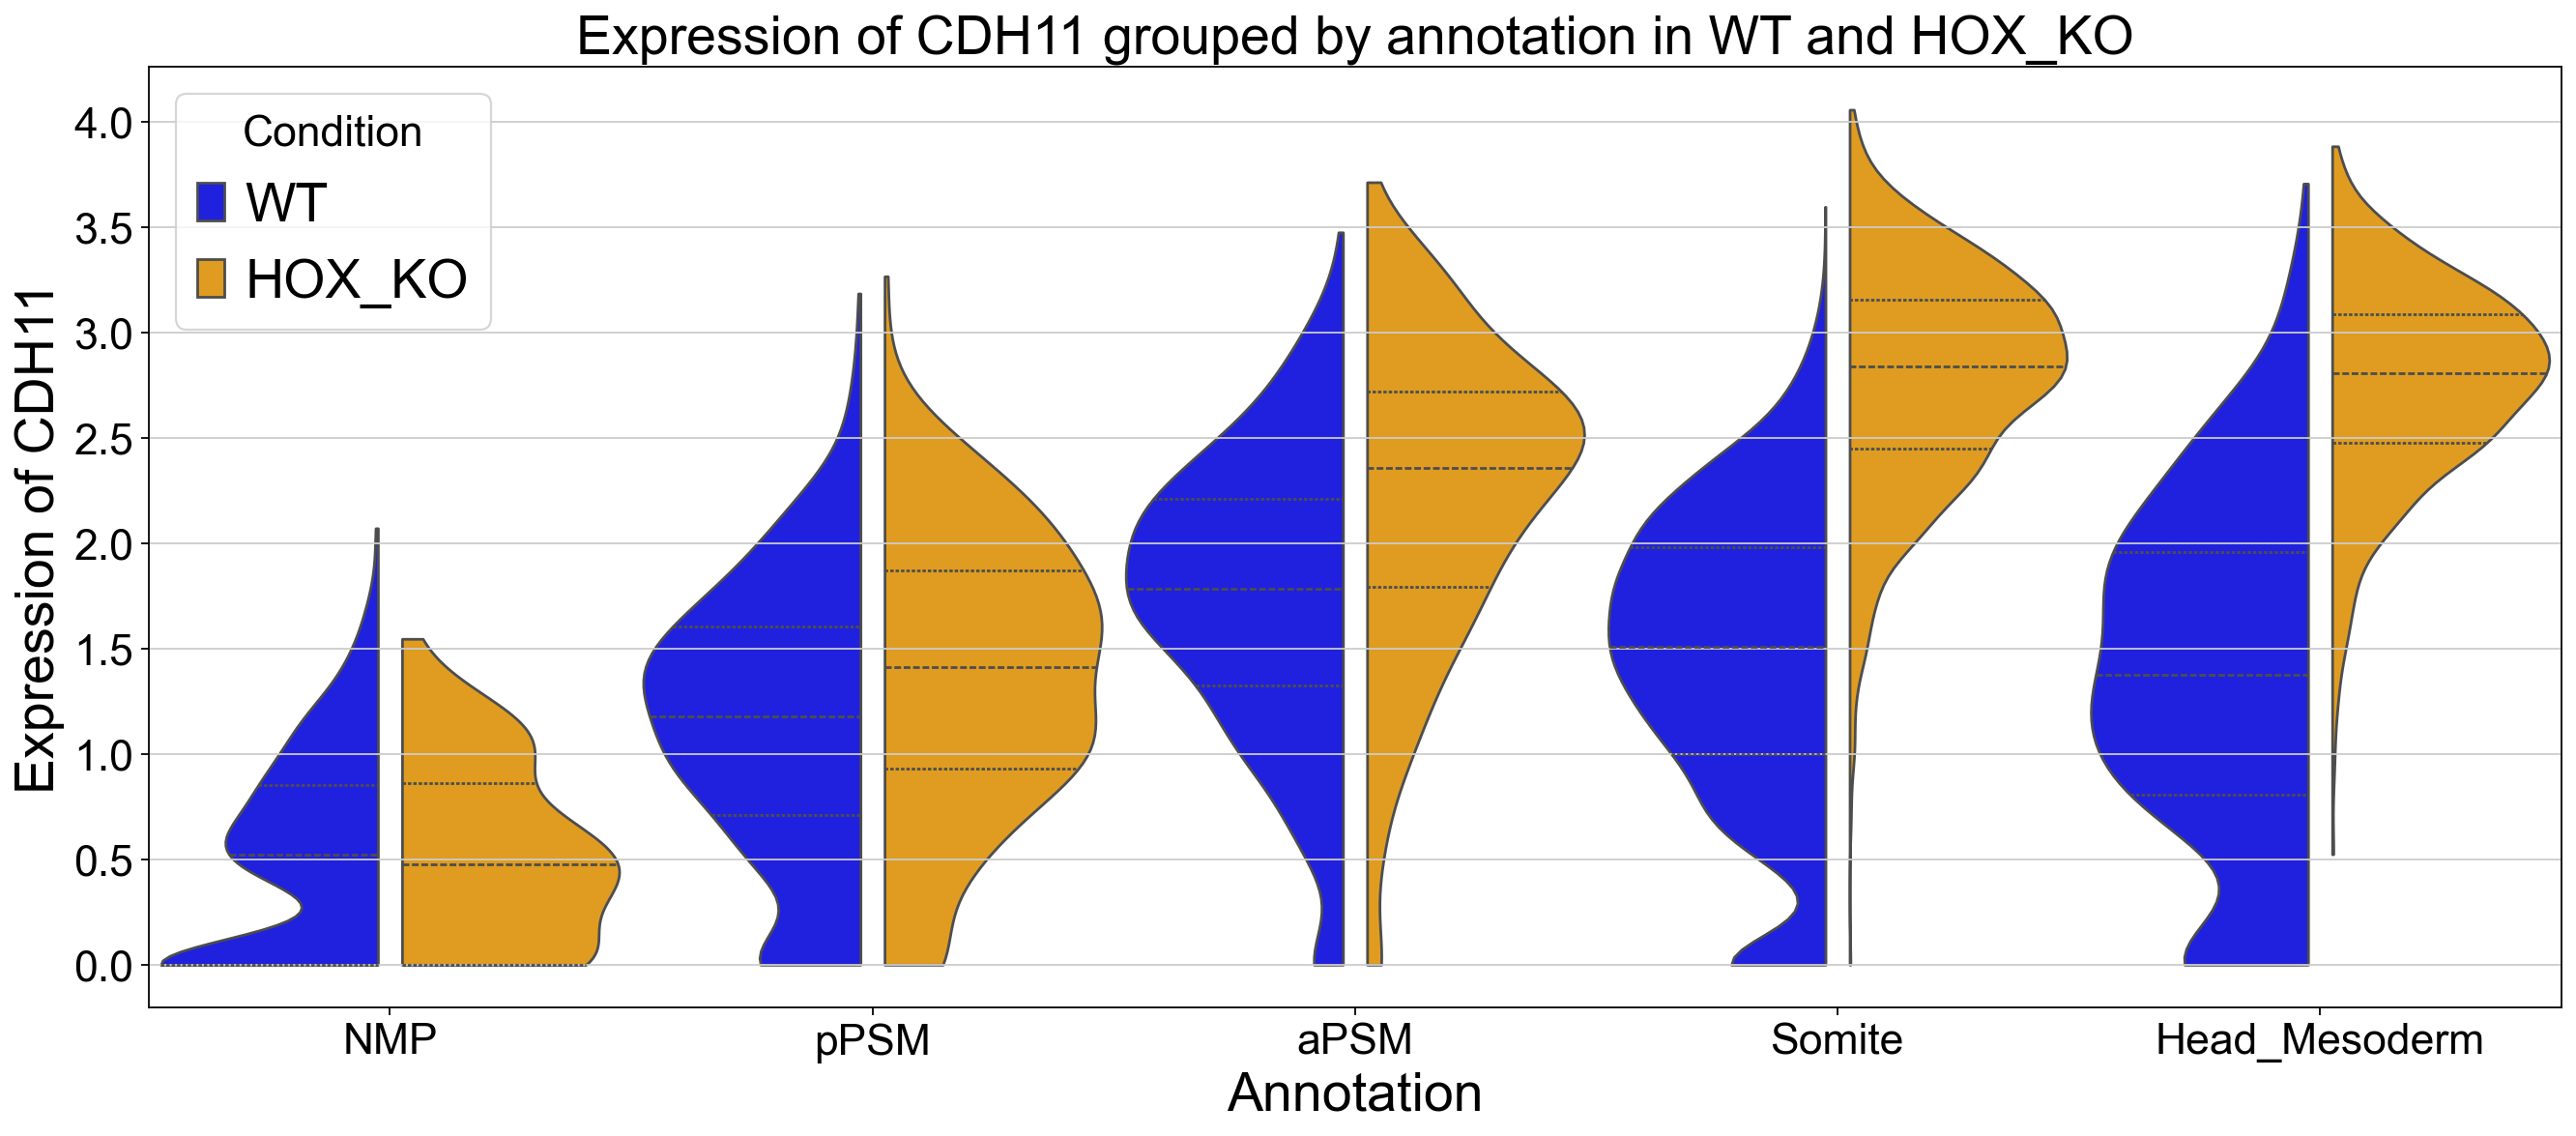

In [20]:
#Split plot of lognorm expression :
gene_of_interest = ["CDH11"]

print(gene_of_interest)

# Specify the two conditions you want to compare
condition_1 = 'WT'
condition_2 = 'HOX_KO'

# Filter the AnnData object to include only the two conditions
adata_filtered = adata_subset[adata_subset.obs['sample'].isin([condition_1, condition_2])]

# Define the order of conditions for plotting
condition_order = [condition_1, condition_2]

# Loop through each gene in the list
for gene in gene_of_interest:
    print(gene)
    # Ensure the gene exists in the data
    if gene not in adata_filtered.var_names:
        print(f"Gene {gene} not found in the dataset.")
        continue
    
    # Extract expression data for the gene (adata.X contains lognorm values)
    gene_expression = adata_filtered[:, gene].X
    
    # Create a DataFrame with the expression data, condition, and annotation labels
    expression_df = pd.DataFrame({
        'expression': gene_expression.A.flatten() if hasattr(gene_expression, 'A') else gene_expression.flatten(),
        'condition': adata_filtered.obs['sample'],
        'annotation': adata_filtered.obs["annotation_short"]
    })
    
    # Set up the matplotlib figure
    plt.figure(figsize=(20, 8))
    
    # Create a split plot using seaborn, grouped by annotation
    sns.violinplot(x='annotation', y='expression', hue='condition', data=expression_df, inner="quart",gap=0.1, density_norm ="width",
                   split=True, palette={condition_1: 'blue', condition_2: 'orange'}, hue_order=condition_order, width=1, cut=0)
    
    # Customize the plot
    plt.title(f"Expression of {gene} grouped by annotation in {condition_1} and {condition_2}", fontsize=25)
    plt.xlabel("Annotation", fontsize=25)
    plt.ylabel(f"Expression of {gene}",fontsize=25)
    plt.legend(title='Condition',title_fontsize=20, fontsize=25)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    # Save the figure before displaying it
    file_name = f'figures/20260107{gene}_expression_violinplot_{condition_1}_vs_{condition_2}.pdf'
    plt.savefig(file_name, format='pdf', dpi=300, bbox_inches='tight')
    
    plt.show()

## PART 2: Generate Violin plot of Additional genes in NMP cluster

 All genotypes included

In [21]:
NMP_violin = adata_subset[adata_subset.obs['annotation_short'] == 'NMP',:].copy()

In [22]:
NMP_violin.obs['sample'] = NMP_violin.obs['sample'].cat.reorder_categories(['WT','HOXD_KO','HOXCD_KO','HOXBCD_KO','HOX_KO'])

In [23]:
list_genes2 = [ "SOX2","TBXT"]

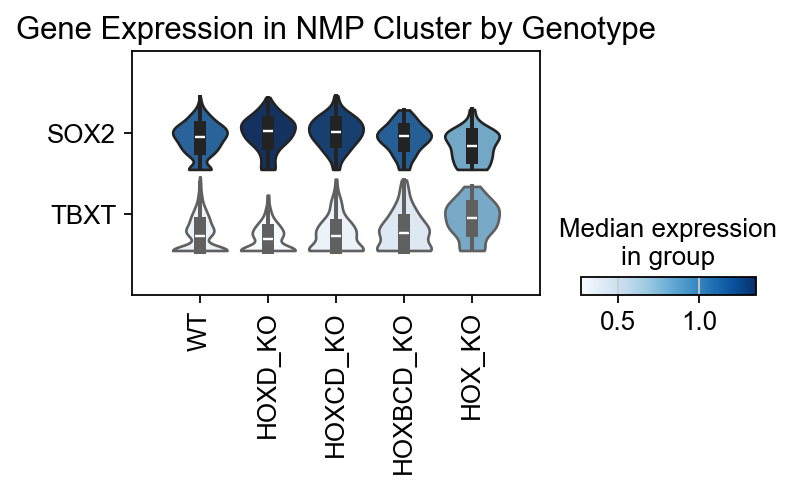

In [24]:
# Create a split violin plot
sc.pl.stacked_violin(
    adata=NMP_violin,
    var_names=list_genes2,
    groupby='sample',  
    swap_axes=True,  # Horizontal layout for better readability
    figsize=(5, len(list_genes2) * 1),  # Dynamically adjust figure size
    title="Gene Expression in NMP Cluster by Genotype",
    density_norm="width",
    inner="box",
    linewidth=1.2,
    save="20260107_NMP_SOX2TBXT_stackedviolin_allgenotypes.pdf"
)

In [25]:
list_genes1 = [ "SOX2","TBXT", "FGF4", "FGF17", "BMP7", "TGFB1", "WNT3A", "WNT5A","WNT8A", "RSPO3", "DRAXIN", "SFRP2"]

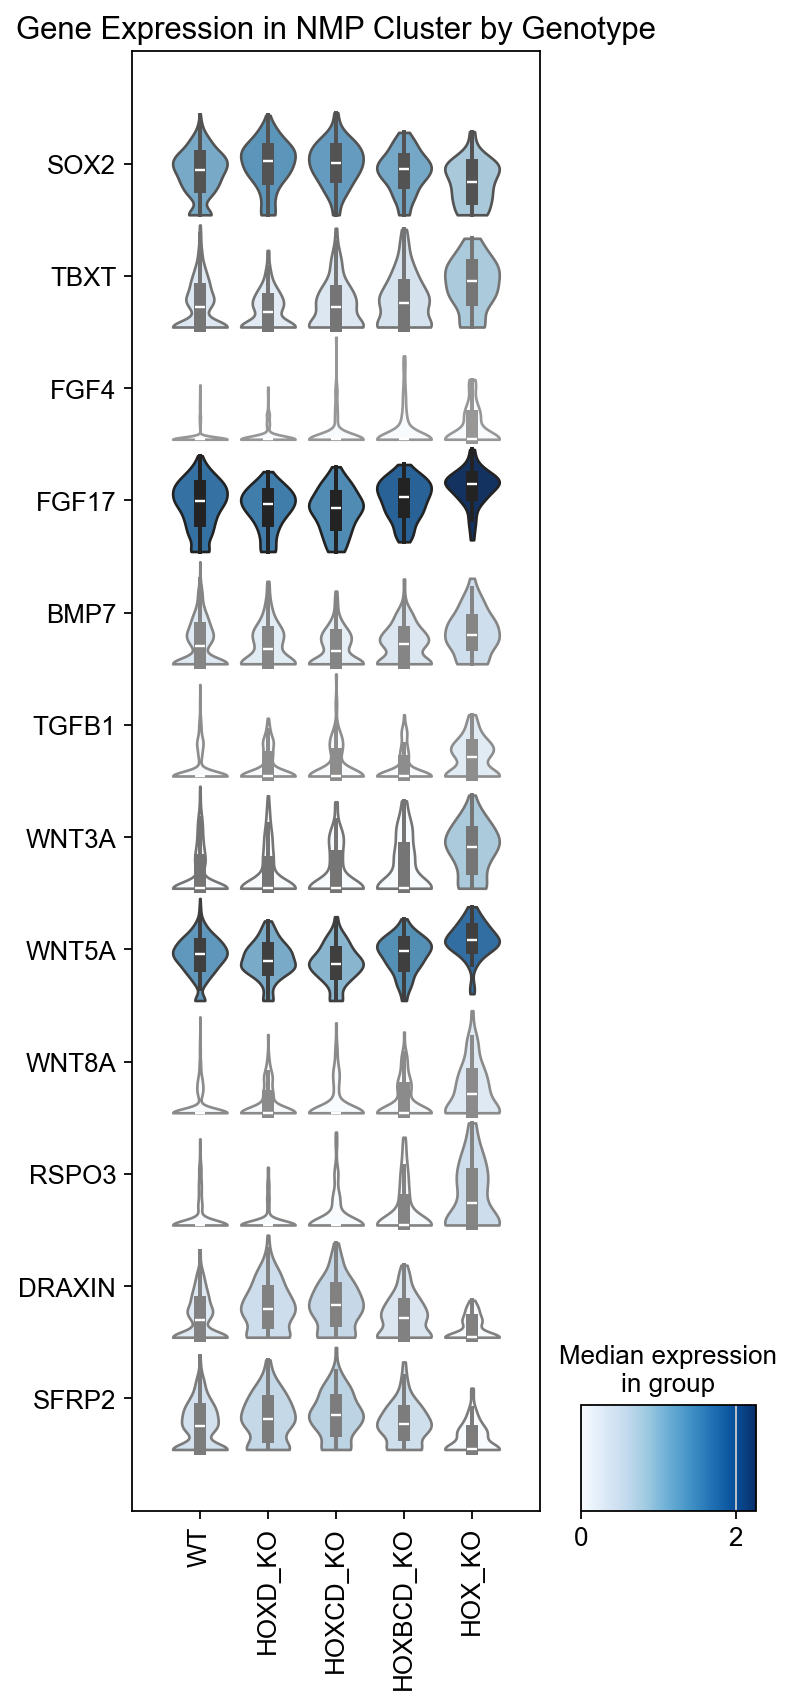

In [26]:
# Create a split violin plot
sc.pl.stacked_violin(
    adata=NMP_violin,
    var_names=list_genes1,
    groupby='sample',  
    swap_axes=True,  # Horizontal layout for better readability
    figsize=(5, len(list_genes1) * 1),  # Dynamically adjust figure size
    title="Gene Expression in NMP Cluster by Genotype",
    density_norm="width",
    inner="box",
    linewidth=1.2,
    save="20260107_NMP_DEGgenes_stackedviolin_allgenotypes.pdf"
)